# Stage 1: Data Cleaning and RFM Segmentation

## 📚 Objectives
- Load Brazilian Olist e-commerce dataset
- Perform data validation and cleaning
- Calculate RFM (Recency, Frequency, Monetary) scores
- Develop and test SQL queries on real data
- Prepare processed data for BI visualization

## 📋 Agenda
1. Import libraries and load raw data
2. Exploratory Data Analysis (EDA)
3. SQL-based RFM calculation
4. Data quality checks
5. Export processed data

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
# import numpy as np
import sqlite3
# from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [20]:
# Load Olist dataset CSV files
# Expected files: olist_orders_dataset.csv, olist_customers_dataset.csv, olist_order_items_dataset.csv

orders_df = pd.read_csv('../data/raw/olist_orders_dataset.csv')
customers_df = pd.read_csv('../data/raw/olist_customers_dataset.csv')
order_items_df = pd.read_csv('../data/raw/olist_order_items_dataset.csv')

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [21]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [5]:
orders_df['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [22]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [40]:
order_items_df.drop(columns=['seller_id'], inplace=True)
order_items_df.head()

,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,2017-02-13 13:57:51,199.90,18.14


In [41]:
data = pd.merge(pd.merge(orders_df, customers_df, on='customer_id', how='left'), order_items_df, on='order_id', how='left')
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-19 20:31:37,19.90,8.72


In [ ]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_item_id'] = data['order_item_id'].fillna(0).astype(int)

In [46]:
data.to_parquet('../data/processed/merged_data.parquet', engine='pyarrow', index=False, compression='snappy')

## 2. Exploratory Data Analysis (EDA)

In [ ]:
# TODO: Examine data shapes, dtypes, null values
# data = pd.read_parquet('../data/processed/merged_data.parquet', engine='pyarrow')

data.info()
print()
print(f"Date range: {data['order_purchase_timestamp'].min()} to {data['order_purchase_timestamp'].max()}")

# Analyze top 10 customers by order count
# Analyze top 10 popular products by quantity sold
# Analyze peak order times (hour of day, day of week)
# Analyze top categories by revenue and quantity sold
# Distribution of order values (total price) and quantities
# Distribution of product prices and quantities

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  object        
 5   order_delivered_carrier_date   111457 non-null  object        
 6   order_delivered_customer_date  110196 non-null  object        
 7   order_estimated_delivery_date  113425 non-null  object        
 8   customer_unique_id             113425 non-null  object        
 9   customer_zip_code_prefix       113425 non-null  int64         
 10  customer_city                  113425 non-null  object        
 11  

In [47]:
duplicates = data[data['order_id'].duplicated()]['order_id']

first_dup_id = duplicates.iloc[6]

investigate_df = data[data['order_id'] == first_dup_id]

investigate_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,shipping_limit_date,price,freight_value
73,68e48e68da1f50f7c5838ea75e3a20dd,4afc1dcca5fe8926fc97d60a4497f8ab,delivered,2018-06-18 16:02:23,2018-06-18 17:00:57,2018-06-19 15:55:00,2018-06-22 21:18:51,2018-07-13 00:00:00,a464f750556546a0989d9326ec003ccf,8220,sao paulo,SP,1,a659cb33082b851fb87a33af8f0fff29,2018-06-22 17:00:57,84.9,13.25
74,68e48e68da1f50f7c5838ea75e3a20dd,4afc1dcca5fe8926fc97d60a4497f8ab,delivered,2018-06-18 16:02:23,2018-06-18 17:00:57,2018-06-19 15:55:00,2018-06-22 21:18:51,2018-07-13 00:00:00,a464f750556546a0989d9326ec003ccf,8220,sao paulo,SP,2,a659cb33082b851fb87a33af8f0fff29,2018-06-22 17:00:57,84.9,13.25
75,68e48e68da1f50f7c5838ea75e3a20dd,4afc1dcca5fe8926fc97d60a4497f8ab,delivered,2018-06-18 16:02:23,2018-06-18 17:00:57,2018-06-19 15:55:00,2018-06-22 21:18:51,2018-07-13 00:00:00,a464f750556546a0989d9326ec003ccf,8220,sao paulo,SP,3,a659cb33082b851fb87a33af8f0fff29,2018-06-22 17:00:57,84.9,13.25
76,68e48e68da1f50f7c5838ea75e3a20dd,4afc1dcca5fe8926fc97d60a4497f8ab,delivered,2018-06-18 16:02:23,2018-06-18 17:00:57,2018-06-19 15:55:00,2018-06-22 21:18:51,2018-07-13 00:00:00,a464f750556546a0989d9326ec003ccf,8220,sao paulo,SP,4,a659cb33082b851fb87a33af8f0fff29,2018-06-22 17:00:57,84.9,13.25


One record for each item in an order

In [48]:
multi_item_orders = data[data.duplicated(subset=['order_id'], keep=False)]

unique_product_counts = multi_item_orders.groupby('order_id')['product_id'].nunique()

# If unique count is 1, they bought the same product multiple times
same_products = unique_product_counts[unique_product_counts == 1]
# If unique count is > 1, they bought different products in the same order
different_products = unique_product_counts[unique_product_counts > 1]

print(f"Total multi-item orders: {len(unique_product_counts)}")
print(f"Orders containing only the SAME product: {len(same_products)}")
print(f"Orders containing DIFFERENT products: {len(different_products)}\n")

if not different_products.empty:
    example_id = different_products.index[0]
    print(f"Example of an order with DIFFERENT products (Order ID: {example_id}):")
    print(data[data['order_id'] == example_id][['order_id', 'product_id']])

Total multi-item orders: 9803
Orders containing only the SAME product: 6567
Orders containing DIFFERENT products: 3236

Example of an order with DIFFERENT products (Order ID: 002f98c0f7efd42638ed6100ca699b42):
                               order_id                        product_id
86306  002f98c0f7efd42638ed6100ca699b42  d41dc2f2979f52d75d78714b378d4068
86307  002f98c0f7efd42638ed6100ca699b42  880be32f4db1d9f6e2bec38fb6ac23ab


An order can contain the same or different products.

In [49]:
# check a duplicate order_id
data[data['order_id'] == '002f98c0f7efd42638ed6100ca699b42']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,shipping_limit_date,price,freight_value
86306,002f98c0f7efd42638ed6100ca699b42,75fd1fb0bb511fc71ac2b2649c02b21b,delivered,2017-08-04 09:19:10,2017-08-04 09:30:15,2017-08-04 18:09:47,2017-08-07 19:07:30,2017-09-05 00:00:00,2e875ea57961ad115cec13fef0920ae6,91910,porto alegre,RS,1,d41dc2f2979f52d75d78714b378d4068,2017-08-10 09:30:15,8.99,32.57
86307,002f98c0f7efd42638ed6100ca699b42,75fd1fb0bb511fc71ac2b2649c02b21b,delivered,2017-08-04 09:19:10,2017-08-04 09:30:15,2017-08-04 18:09:47,2017-08-07 19:07:30,2017-09-05 00:00:00,2e875ea57961ad115cec13fef0920ae6,91910,porto alegre,RS,2,880be32f4db1d9f6e2bec38fb6ac23ab,2017-08-10 09:30:15,44.90,7.16


In [26]:
# top 10 customers by order count
top_customers = pd.DataFrame(data.groupby('customer_unique_id')
                             .agg({'order_id': 'nunique'})
                             .rename(columns={'order_id': 'order_count'})
                             .sort_values('order_count', ascending=False)
                             .head(10)).reset_index().rename(columns={0: 'order_count'})
pd.merge(top_customers, customers_df[['customer_unique_id', 'customer_city', 'customer_state']].drop_duplicates(), on='customer_unique_id', how='left')

,customer_unique_id,order_count,customer_city,customer_state
0,8d50f5eadf50201ccdcedfb9e2ac8455,17,sao paulo,SP
1,3e43e6105506432c953e165fb2acf44c,9,praia grande,SP
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7,ituiutaba,MG
3,6469f99c1f9dfae7733b25662e7f1782,7,santos,SP
4,ca77025e7201e3b30c44b472ff346268,7,recife,PE
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,jandira,SP
6,12f5d6e1cbf93dafd9dcc19095df0b3d,6,curitiba,PR
7,63cfc61cee11cbe306bff5857d00bfe4,6,rio de janeiro,RJ
8,dc813062e0fc23409cd255f7f53c7074,6,garanhuns,PE
9,de34b16117594161a6a89c50b289d35a,6,santo andre,SP


In [38]:
# top 10 popular products by quantity sold
data.groupby('product_id').size().sort_values(ascending=False).head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64

Text(0, 0.5, 'Number of Orders')

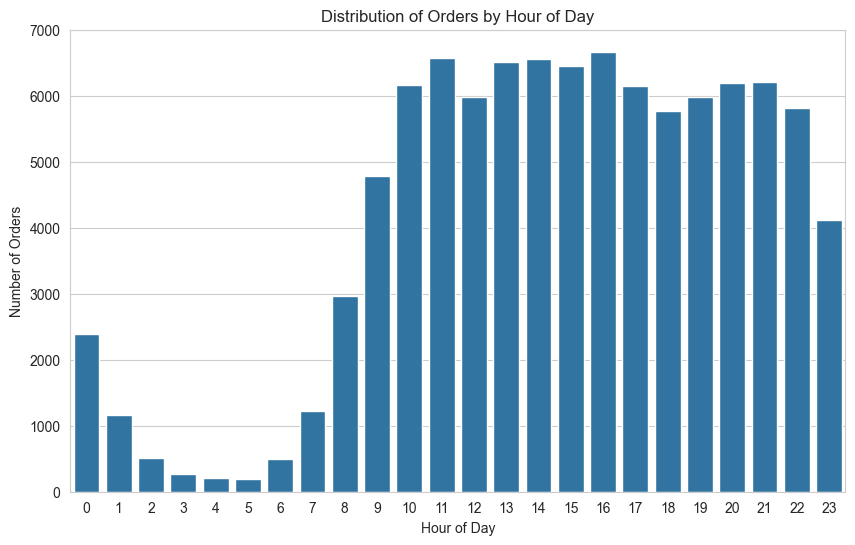

In [22]:
# peak order times
order_hours = orders_df['order_purchase_timestamp'].dt.hour.value_counts().sort_index()

# plot order hours
plt.figure(figsize=(10, 6))
sns.barplot(x=order_hours.index, y=order_hours.values)
plt.title('Distribution of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')

Text(0, 0.5, 'Number of Orders')

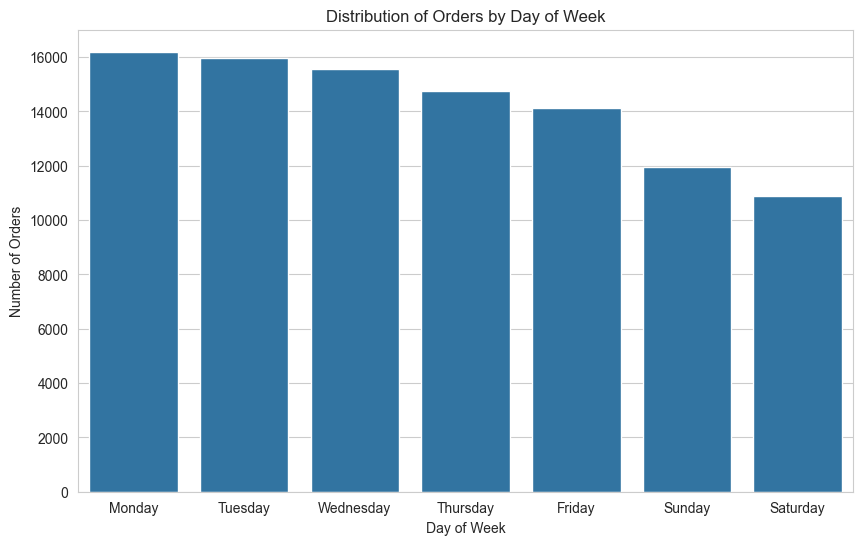

In [24]:
order_day_of_week = orders_df['order_purchase_timestamp'].dt.day_name().value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=order_day_of_week.index, y=order_day_of_week.values)
plt.title('Distribution of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')

Text(0, 0.5, 'Frequency')

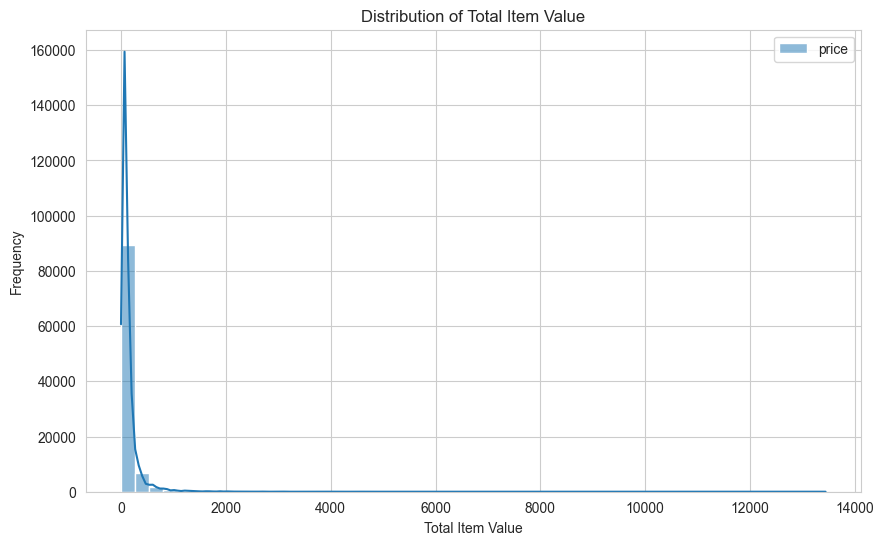

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data.groupby('order_id').agg({'price': 'sum'}), bins=50, kde=True)
plt.title('Distribution of Total Item Value')
plt.xlabel('Total Item Value')
plt.ylabel('Frequency')

## 3. Create Local Database and Load Data

In [ ]:
# Create SQLite database and load dataframes
with sqlite3.connect('../data/ecommerce.db') as conn:
    orders_df.to_sql('orders', conn, if_exists='replace', index=False)
    customers_df.to_sql('customers', conn, if_exists='replace', index=False)
    order_items_df.to_sql('order_items', conn, if_exists='replace', index=False)
    data.to_sql('merged', conn, if_exists='replace', index=False)

## 4. Calculate RFM Scores using SQL

In [50]:
# This SQL should:
# - Calculate Recency (days since last purchase)
# - Calculate Frequency (total number of purchases)
# - Calculate Monetary (total amount spent)
# - Use NTILE to create scores 1-5 for each dimension

rfm_query = """
WITH user_purchase_stats AS (
    SELECT 
        customer_unique_id,
        MAX(order_purchase_timestamp) as last_purchase_date,
        COUNT(DISTINCT order_id) as purchase_count,
        SUM(price) as total_monetary
    FROM merged
    GROUP BY customer_unique_id
),
rfm_scores AS (
    SELECT 
        customer_unique_id,
        last_purchase_date,
        purchase_count,
        total_monetary,
        NTILE(5) OVER (ORDER BY last_purchase_date) as recency_score,
        NTILE(5) OVER (ORDER BY purchase_count DESC) as frequency_score,
        NTILE(5) OVER (ORDER BY total_monetary DESC) as monetary_score
    FROM user_purchase_stats
)
SELECT * FROM rfm_scores;
"""

with sqlite3.connect('../data/ecommerce.db') as conn:
    rfm_df = pd.read_sql_query(rfm_query, conn)

# Expected outcome: DataFrame with columns: customer_id, recency, frequency, monetary, r_score, f_score, m_score
rfm_df.head()

,customer_unique_id,last_purchase_date,purchase_count,total_monetary,recency_score,frequency_score,monetary_score
0,b7d76e111c89f7ebf14761390f0f7d17,2016-09-04 21:15:19,1,72.89,1,3,3
1,4854e9b3feff728c13ee5fc7d1547e92,2016-09-05 00:15:34,1,59.50,1,4,4
2,009b0127b727ab0ba422f6d9604487c7,2016-09-13 15:24:19,1,NaN,1,5,5
3,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38,1,134.97,1,2,2
4,0eb1ee9dba87f5b36b4613a65074337c,2016-10-02 22:07:52,1,100.00,1,3,3


### 📌 Implementation Task: Complete SQL Queries and RFM Model

**After validating RFM logic in this notebook, complete these:**

#### 1. SQL Queries → `src/data_pipeline/sql_queries.py`
- Complete the `RFM_CALCULATION_QUERY` with NTILE window functions
- Use `NTILE(5) OVER (ORDER BY ...)` to create quintile scores (1-5)
- Example pattern: `NTILE(5) OVER (ORDER BY last_purchase_date DESC) as recency_score`

#### 2. RFM Model Class → `src/analysis/rfm_model.py`
Implement these methods in the `RFMModel` class:
- `calculate_rfm_scores(recency_col, frequency_col, monetary_col)` 
  - Input: columns with recency (days), frequency (count), monetary (amount)
  - Output: DataFrame with R_score, F_score, M_score (each 1-5)
  - Use `pd.qcut()` to create quintiles: `pd.qcut(df['recency'], 5, labels=[5,4,3,2,1])`
  - Note: Recency is inverse (lower days = higher score)

**Key Pattern for Python Implementation:**
```python
# Reverse ranking for recency (more recent = higher score)
df['r_score'] = pd.qcut(df['recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
# Normal ranking for frequency and monetary (more = higher score)
df['f_score'] = pd.qcut(df['frequency'], 5, labels=[1,2,3,4,5], duplicates='drop')
df['m_score'] = pd.qcut(df['monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')
```

## 5. Validate RFM Results

In [ ]:
# TODO: Validate RFM calculation
# - Check for null values
# - Verify score distributions
# - Inspect high-value vs low-value customer segments

In [11]:
rfm_df['purchase_count'].value_counts()

purchase_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Most customers only bought once, but their scores ranges from 1 to 5. We want to have the same score for the same purchase_count.

### Updated implementation with Python

In [ ]:
rfm_df = data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'last_purchase_date',
    'order_id': 'purchase_count',
    'price': 'total_monetary'
})

rfm_df.head()

,last_purchase_date,purchase_count,total_monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [4]:
rfm_df['r_score'] = pd.qcut(rfm_df['last_purchase_date'], 5, labels=[1,2,3,4,5], duplicates='drop')
rfm_df['m_score'] = pd.qcut(rfm_df['total_monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')
rfm_df['m_score'].value_counts()

m_score
1    19912
2    19292
4    19206
5    19186
3    18500
Name: count, dtype: int64

In [5]:
rfm_df['f_score'] = rfm_df['purchase_count'].apply(lambda count: count if count <= 4 else 5)
rfm_df['f_score'].value_counts()

f_score
1    93099
2     2745
3      203
4       30
5       19
Name: count, dtype: int64

### 📌 Implementation Task: RFM Validation Logic

**After validating in this notebook, implement in:** `src/analysis/rfm_model.py`

Add validation to the `RFMModel.__init__()` method to check:
- ✅ RFM scores are in valid range (1-5 for each dimension)
- ✅ No null values in R_score, F_score, M_score
- ✅ Raise `ValueError` if validation fails

**Test these validations here before implementing:**
- Check `rfm_df['r_score'].min()` and `.max()` are in [1, 5]
- Check `rfm_df[['r_score', 'f_score', 'm_score']].isnull().sum()` is 0
- Verify top/bottom 10 customers have sensible values

In [6]:
rfm_df[['r_score', 'f_score', 'm_score']].isnull().sum()

r_score    0
f_score    0
m_score    0
dtype: int64

In [28]:
pd.merge(top_customers, rfm_df, on='customer_unique_id', how='left').drop(columns=['purchase_count'])

,customer_unique_id,order_count,last_purchase_date,total_monetary,r_score,m_score,f_score
0,8d50f5eadf50201ccdcedfb9e2ac8455,17,2018-08-20 19:14:26,729.62,5,5,5
1,3e43e6105506432c953e165fb2acf44c,9,2018-02-27 18:36:39,1252.25,3,5,5
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7,2018-02-14 13:22:12,997.20,3,5,5
3,6469f99c1f9dfae7733b25662e7f1782,7,2018-06-28 00:43:34,714.00,5,5,5
4,ca77025e7201e3b30c44b472ff346268,7,2018-06-01 11:38:29,1029.52,5,5,5
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,2018-01-24 15:15:26,886.50,3,5,5
6,12f5d6e1cbf93dafd9dcc19095df0b3d,6,2017-01-05 15:25:10,58.40,1,2,5
7,63cfc61cee11cbe306bff5857d00bfe4,6,2018-05-28 17:20:02,773.78,5,5,5
8,dc813062e0fc23409cd255f7f53c7074,6,2018-08-23 00:07:26,1152.76,5,5,5
9,de34b16117594161a6a89c50b289d35a,6,2018-01-17 23:34:21,486.00,3,5,5


## 6. Order Pattern discovery


In [ ]:
# TODO:  Find out customer order patterns and relationships between RFM scores and customer behavior
# Segment customers based on RFM scores (e.g., champion, loyal, at-risk, new, need attention)
# - Analyze how RFM scores correlate with seasonality, average item price, and customer demographics
# - Find out pattern for champions (what categories do they purchase most?) and at-risk customers (geography, demographics, product categories) 

### 📌 Implementation Task: Customer Segmentation Logic

**After analyzing patterns in this notebook, implement in:** `src/analysis/rfm_model.py`

Implement these methods in the `RFMModel` class:

1. `segment_customers()`
   - Combine R, F, M scores to create customer segments
   - Map RFM combinations to business-friendly names
   - Output: DataFrame with 'segment' column added

2. `get_segment_metrics()`
   - Calculate per-segment statistics:
     - Customer count per segment
     - Average monetary value per segment
     - Average frequency per segment
   - Output: Summary DataFrame showing metrics by segment

**Segment Mapping Examples to Test:**
```
(5,5,5) → "Champions"      (Recent, Frequent, High-value)
(4-5, 4-5, 4-5) → "Loyal"  (Consistent performers)
(1-2, *, *) → "At-Risk"    (Haven't purchased recently)
(5, 1, *) → "New"          (Just started buying)
(3, 3, 3) → "Need Attention" (Middle performers)
```

In [35]:
def segment_customer(row):
    if row['r_score'] == 5 and row['f_score'] == 5 and row['m_score'] == 5:
        return 'Champion'
    elif row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Loyal'
    elif row['r_score'] <= 2:
        return 'At Risk'
    elif row['r_score'] == 5 and row['f_score'] == 1:
        return 'New'
    else:
        return 'Need Attention'
    
rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)
rfm_df['segment'].value_counts()

segment
Need Attention    39093
At Risk           38439
New               18530
Loyal                26
Champion              8
Name: count, dtype: int64

In [ ]:
# rfm_df = pd.read_parquet('../data/processed/rfm_segments.parquet', engine='pyarrow')
rfm_df.head()

,last_purchase_date,purchase_count,total_monetary,r_score,m_score,f_score,segment
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,4,4,1,Need Attention
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,4,1,1,Need Attention
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,1,2,1,At Risk
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,2,1,1,At Risk
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,2,4,1,At Risk


In [ ]:
# champions

pd.merge(
    rfm_df[rfm_df['segment'] == 'Champion'], 
    data, 
    on='customer_unique_id', 
    how='left'
    ).drop_duplicates(subset=['customer_unique_id'])[['customer_unique_id', 'last_purchase_date', 'purchase_count', 'total_monetary', 'customer_city', 'customer_state']]

,customer_unique_id,last_purchase_date,purchase_count,total_monetary,customer_city,customer_state
0,394ac4de8f3acb14253c177f0e15bc58,2018-08-15 18:01:23,5,702.16,sao paulo,SP
6,4e65032f1f574189fb793bac5a867bbc,2018-06-14 09:28:49,5,408.06,sao caetano do sul,SP
12,63cfc61cee11cbe306bff5857d00bfe4,2018-05-28 17:20:02,6,773.78,rio de janeiro,RJ
23,6469f99c1f9dfae7733b25662e7f1782,2018-06-28 00:43:34,7,714.00,santos,SP
32,8d50f5eadf50201ccdcedfb9e2ac8455,2018-08-20 19:14:26,17,729.62,sao paulo,SP
49,ca77025e7201e3b30c44b472ff346268,2018-06-01 11:38:29,7,1029.52,recife,PE
61,dc813062e0fc23409cd255f7f53c7074,2018-08-23 00:07:26,6,1152.76,garanhuns,PE
72,fe81bb32c243a86b2f86fbf053fe6140,2018-06-21 12:10:25,5,1535.40,sao paulo,SP


In [14]:
# at risk

at_risk_customers = pd.merge(
    rfm_df[rfm_df['segment'] == 'At Risk'], 
    data, 
    on='customer_unique_id', 
    how='left'
    ).drop_duplicates(subset=['customer_unique_id'])[['customer_unique_id', 'last_purchase_date', 'purchase_count', 'total_monetary', 'customer_city', 'customer_state']]
at_risk_customers['customer_state'].value_counts().head(10)

customer_state
SP    14986
RJ     5313
MG     4623
RS     2310
PR     1940
SC     1489
BA     1368
ES      830
GO      802
DF      776
Name: count, dtype: int64

In [15]:
at_risk_customers.describe()

,last_purchase_date,purchase_count,total_monetary
count,38439,38439.000000,38439.000000
mean,2017-07-29 03:38:05.808475648,1.029631,161.541861
min,2016-09-04 21:15:19,1.000000,0.000000
25%,2017-05-18 20:53:02.500000,1.000000,46.900000
50%,2017-08-10 11:46:57,1.000000,89.900000
75%,2017-10-19 10:24:52.500000,1.000000,166.990000
max,2017-12-03 17:42:45,6.000000,60480.000000
std,NaN,0.184134,448.109808


## 6. Export Processed Data

In [37]:
# TODO: Save RFM calculations to processed data folder
rfm_df.to_csv('../data/processed/rfm_segments.csv', index=True)
rfm_df.to_parquet('../data/processed/rfm_segments.parquet', engine='pyarrow', index=True)

print("Data processing complete!")

Data processing complete!


### 📌 Implementation Task: Local Data Export

**After validating exports in this notebook:**

Save processed RFM data locally to `data/processed/`:
- `rfm_segments.csv` - Main RFM scores with R_score, F_score, M_score
- `customer_segments.csv` - Customer IDs with assigned segment names
- `segment_metrics.csv` - Aggregate statistics by segment

**Note:** AWS S3 export will happen in Notebook 2 using `src/data_pipeline/aws_client.py`

Test your exports by re-reading CSV files and verifying structure matches original DataFrames.